# Black–Scholes–Merton options

How volatility, moneyness and dividends shape European option values.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A European call separates upside participation from ownership of the underlying. The question here is how much that convex payoff is worth when volatility, financing and dividends are specified, and which input drives a local hedge.

For spot $S$, strike $K$, maturity $T$, continuous rates $r,q$ and volatility $\sigma$,

$$C=Se^{-qT}\Phi(d_1)-Ke^{-rT}\Phi(d_2),\qquad d_1=\frac{\log(S/K)+(r-q+\sigma^2/2)T}{\sigma\sqrt T},\quad d_2=d_1-\sigma\sqrt T.$$

The exercise fixes $S=K=100$, $T=1$, $r=4\%$, $q=1\%$ and $\sigma=20\%$. A direct normal-distribution formula is compared with QuantLib's analytic European engine; call–put parity and a finite-difference delta provide separate checks. A volatility sweep shows the economic role of convexity.

Delta is measured per unit of spot. Vega describes a change in volatility, so a one-percentage-point volatility move is 0.01 in the formula's decimal units. These are model sensitivities under a constant-volatility diffusion; they do not estimate implied volatility, realized hedge costs, jump risk or a volatility smile. The contract is European and pays a continuous dividend yield; discrete dividends and American exercise need other models.

[QuantLib's analytic engine](https://github.com/lballabio/QuantLib/blob/master/ql/pricingengines/vanilla/analyticeuropeanengine.cpp) is the implementation reference; all numerical inputs are original illustrative assumptions.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from scipy.stats import norm
S, K, T, r, q, sigma = 100.0, 100.0, 1.0, .04, .01, .20
def call_price(spot, vol):
    d1 = (np.log(spot / K) + (r-q+vol**2/2)*T)/(vol*np.sqrt(T))
    d2 = d1-vol*np.sqrt(T)
    return spot*np.exp(-q*T)*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
call = call_price(S, sigma)
d1 = (np.log(S/K)+(r-q+sigma**2/2)*T)/(sigma*np.sqrt(T))
d2 = d1-sigma*np.sqrt(T)
put = K*np.exp(-r*T)*norm.cdf(-d2)-S*np.exp(-q*T)*norm.cdf(-d1)
with valuation_date():
    dc = ql.Actual365Fixed()
    process = ql.BlackScholesMertonProcess(
        ql.QuoteHandle(ql.SimpleQuote(S)),
        ql.YieldTermStructureHandle(ql.FlatForward(DATE, q, dc)),
        ql.YieldTermStructureHandle(ql.FlatForward(DATE, r, dc)),
        ql.BlackVolTermStructureHandle(ql.BlackConstantVol(DATE, ql.NullCalendar(), sigma, dc)))
    option = ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call, K), ql.EuropeanExercise(DATE+365))
    option.setPricingEngine(ql.AnalyticEuropeanEngine(process))
    ql_price, ql_delta = option.NPV(), option.delta()
finite_delta = (call_price(S+.001, sigma)-call_price(S-.001, sigma))/.002
assert abs(call-ql_price) < 1e-10
assert abs(call-put-(S*np.exp(-q*T)-K*np.exp(-r*T))) < 1e-10
assert abs(finite_delta-ql_delta) < 1e-7
display(pd.DataFrame([{'call_formula':call, 'call_QuantLib':ql_price, 'put':put, 'delta':ql_delta, 'finite_difference_delta':finite_delta}]))

,call_formula,call_QuantLib,put,delta,finite_difference_delta
0,9.319738,9.319738,6.393699,0.592749,0.592749


## Economic relationship

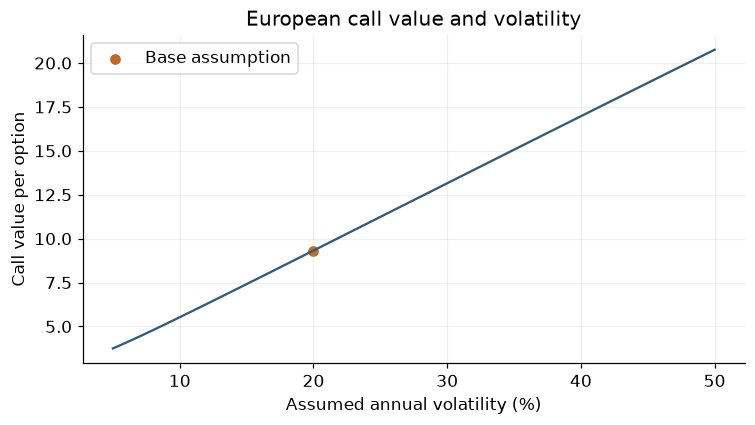

In [3]:
vols = np.linspace(.05, .50, 60)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(100*vols, [call_price(S,v) for v in vols], color='#315b7d')
ax.scatter([100*sigma],[call],color='#bc6c25',label='Base assumption')
ax.set(xlabel='Assumed annual volatility (%)', ylabel='Call value per option', title='European call value and volatility')
ax.legend(); fig.tight_layout(); plt.show()

## Interpretation

The formula, QuantLib price and parity agree. The increasing value across the volatility sweep reflects the convex call payoff under this model; it is not an empirical volatility premium.